# Objective:

Analyze and visualize trends in pollution emissions in the U.S. over time using EPA data.

Identify key insights such as:

Which states or regions have the highest pollution levels?

How have emissions changed over the years?

Which pollutants are most prevalent?

In [87]:
import pandas as pd 

In [89]:
df = pd.read_csv('pollution_2000_2023.csv')

In [90]:
df.head()

,Unnamed: 0,Date,Address,State,County,City,O3 Mean,O3 1st Max Value,O3 1st Max Hour,O3 AQI,...,CO 1st Max Hour,CO AQI,SO2 Mean,SO2 1st Max Value,SO2 1st Max Hour,SO2 AQI,NO2 Mean,NO2 1st Max Value,NO2 1st Max Hour,NO2 AQI
0,0,2000-01-01,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.019765,0.040,10,37,...,23,25.0,3.000000,9.0,21,13.0,19.041667,49.0,19,46
1,1,2000-01-02,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.015882,0.032,10,30,...,0,26.0,1.958333,3.0,22,4.0,22.958333,36.0,19,34
2,2,2000-01-03,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.009353,0.016,9,15,...,8,28.0,5.250000,11.0,19,16.0,38.125000,51.0,8,48
3,3,2000-01-04,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.015882,0.033,9,31,...,23,34.0,7.083333,16.0,8,23.0,40.260870,74.0,8,72
4,4,2000-01-05,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.007353,0.012,9,11,...,2,42.0,8.708333,15.0,7,21.0,48.450000,61.0,22,58


In [93]:
df.describe()

,Unnamed: 0,O3 Mean,O3 1st Max Value,O3 1st Max Hour,O3 AQI,CO Mean,CO 1st Max Value,CO 1st Max Hour,CO AQI,SO2 Mean,SO2 1st Max Value,SO2 1st Max Hour,SO2 AQI,NO2 Mean,NO2 1st Max Value,NO2 1st Max Hour,NO2 AQI
count,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000,665414.000000
mean,332706.500000,0.028605,0.038980,10.766409,39.137872,0.329459,0.465604,5.922553,5.247399,1.428759,3.931057,8.867280,5.154743,11.510561,23.253519,11.588897,21.766209
std,192088.620349,0.012151,0.014912,3.297315,22.253413,0.275725,0.434542,7.719537,5.010467,2.410071,7.700799,6.776779,10.371465,8.957527,15.264335,7.888301,14.447780
min,0.000000,-0.000706,0.000000,7.000000,0.000000,-0.437500,-0.400000,0.000000,0.000000,-2.508333,-2.300000,0.000000,0.000000,-4.629167,-4.400000,0.000000,0.000000
25%,166353.250000,0.019824,0.029000,9.000000,27.000000,0.175000,0.200000,0.000000,2.000000,0.173913,0.600000,3.000000,0.000000,4.860870,11.000000,5.000000,10.000000
50%,332706.500000,0.028353,0.038000,10.000000,35.000000,0.258333,0.300000,1.000000,3.000000,0.604167,1.400000,8.000000,1.000000,9.304348,21.000000,9.000000,20.000000
75%,499059.750000,0.036882,0.048000,11.000000,44.000000,0.408696,0.600000,9.000000,7.000000,1.604545,4.000000,13.000000,6.000000,15.958333,33.000000,20.000000,31.000000
max,665413.000000,0.107353,0.140000,23.000000,237.000000,7.508333,15.500000,23.000000,201.000000,321.625000,351.000000,23.000000,200.000000,140.650000,371.700000,23.000000,153.000000


In [95]:
df.isnull().sum()

Unnamed: 0           0
Date                 0
Address              0
State                0
County               0
City                 0
O3 Mean              0
O3 1st Max Value     0
O3 1st Max Hour      0
O3 AQI               0
CO Mean              0
CO 1st Max Value     0
CO 1st Max Hour      0
CO AQI               0
SO2 Mean             0
SO2 1st Max Value    0
SO2 1st Max Hour     0
SO2 AQI              0
NO2 Mean             0
NO2 1st Max Value    0
NO2 1st Max Hour     0
NO2 AQI              0
dtype: int64

In [97]:
df = df.dropna()

In [99]:
print("Headline of the Dataset (Column Names):")
print(df.columns)


Headline of the Dataset (Column Names):
Index(['Unnamed: 0', 'Date', 'Address', 'State', 'County', 'City', 'O3 Mean',
       'O3 1st Max Value', 'O3 1st Max Hour', 'O3 AQI', 'CO Mean',
       'CO 1st Max Value', 'CO 1st Max Hour', 'CO AQI', 'SO2 Mean',
       'SO2 1st Max Value', 'SO2 1st Max Hour', 'SO2 AQI', 'NO2 Mean',
       'NO2 1st Max Value', 'NO2 1st Max Hour', 'NO2 AQI'],
      dtype='object')


In [101]:

df['Year'] = pd.to_datetime(df['Date']).dt.year
yearly_pollution = df.groupby('Year')[['NO2 Mean', 'O3 Mean', 'SO2 Mean', 'CO Mean']].mean()

 states have the highest pollution levels


In [108]:
state_pollution = df.groupby('State')['NO2 Mean'].mean().sort_values(ascending=False)
print(state_pollution.head())

State
Colorado         18.125796
New York         17.401809
Arizona          16.995758
Massachusetts    16.160249
New Jersey       16.134109
Name: NO2 Mean, dtype: float64


which pollution is most prevalent

In [113]:
pollutant_means = df[['NO2 Mean', 'O3 Mean' , 'SO2 Mean' , 'CO Mean']].mean()
print(pollutant_means)


NO2 Mean    11.510561
O3 Mean      0.028605
SO2 Mean     1.428759
CO Mean      0.329459
dtype: float64


In [131]:
df['Date']=pd.to_datetime(df['Date'])

In [133]:

df['Year'] = pd.to_datetime(df['Date']).dt.year
yearly_pollution = df.groupby('Year')[['NO2 Mean', 'O3 Mean', 'SO2 Mean', 'CO Mean']].mean()

<Axes: title={'center': 'Pollution Trends Over Time'}, xlabel='Year'>

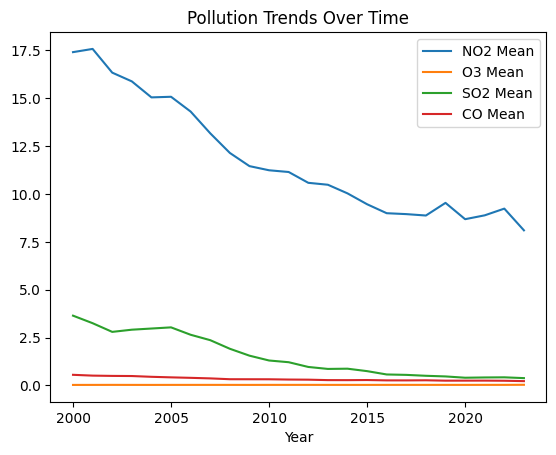

In [139]:
yearly_pollution.plot(kind='line', title='Pollution Trends Over Time')

Visualize the Data


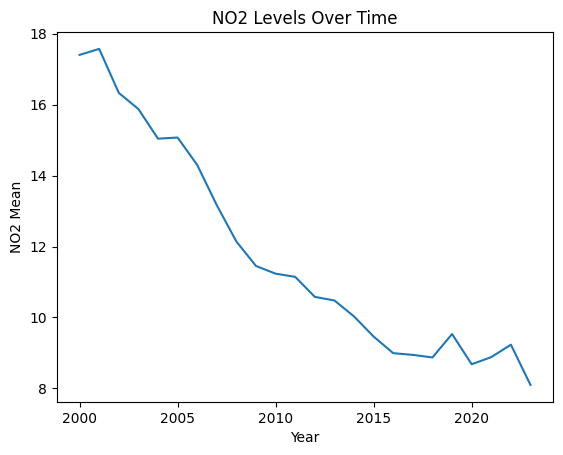

In [147]:
# Analyze Pollution Trends
import seaborn as sns 
import matplotlib.pyplot as plt 
sns.lineplot(x='Year' , y = 'NO2 Mean' , data = yearly_pollution.reset_index())
plt.title('NO2 Levels Over Time')
plt.show()             

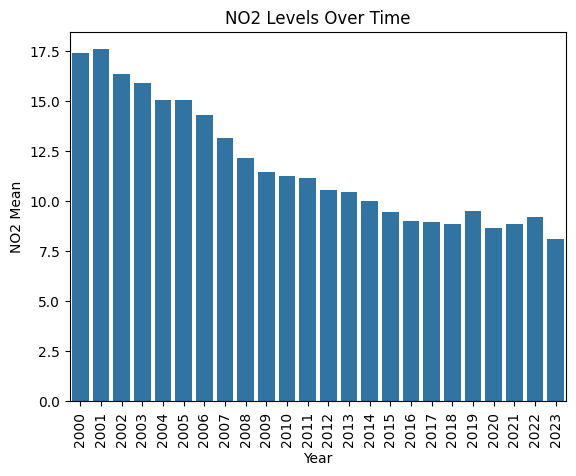

In [157]:
# Analyze Pollution Trends
import seaborn as sns 
import matplotlib.pyplot as plt 
sns.barplot(x='Year' , y = 'NO2 Mean' , data = yearly_pollution.reset_index())
plt.xticks(rotation=90)
plt.title('NO2 Levels Over Time')
plt.show()             

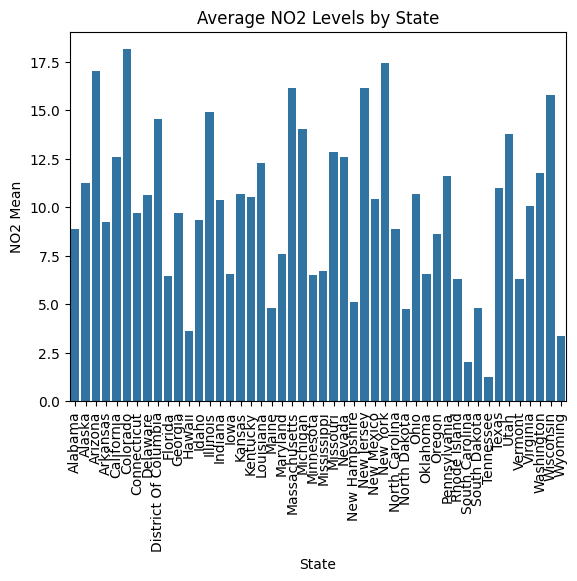

In [155]:
sns.barplot(x='State' , y='NO2 Mean' , data=df.groupby('State')['NO2 Mean'].mean().reset_index())
plt.title('Average NO2 Levels by State')
plt.xticks(rotation=90)
plt.show()


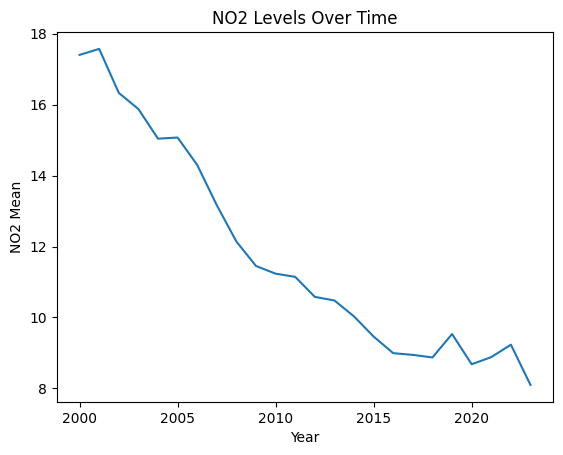

In [159]:

# Group data by year and calculate mean NO2 levels
yearly_no2 = df.groupby('Year')['NO2 Mean'].mean().reset_index()

# Create a line plot
sns.lineplot(x='Year', y='NO2 Mean', data=yearly_no2)
plt.title('NO2 Levels Over Time')
plt.xlabel('Year')
plt.ylabel('NO2 Mean')
plt.show()

In [163]:
df.to_csv("cleaned_data.csv", index=False)
d=pd.read_csv('cleaned_data.csv')